# One-Class Classification: Rowing Stroke Quality Detection

## Table of Contents
1. [Motivation](#motivation)
2. [Data Loading](#data-loading)
3. [Feature Engineering](#feature-engineering)
4. [Train/Test Split](#traintest-split)
5. [Model Selection](#model-selection)
6. [Implementation](#implementation)
7. [Hyperparameter Tuning](#hyperparameter-tuning)
8. [Evaluation Metrics](#evaluation-metrics)
9. [Comparative Analysis](#comparative-analysis)


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
    average_precision_score
)

RANDOM_STATE = 42
PROJECT_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "requirements.txt").exists()
)
NORM_DIR = PROJECT_ROOT / "1_DatasetCharacteristics" / "landmarks" / "normalized"


## Motivation

The baseline model (Random Forest, supervised) suffers from a fundamental data problem: BAD recordings come from only one or two specific videos. A supervised model therefore does not learn *what bad technique looks like* — it learns *what those specific BAD videos look like* (lighting, camera angle, rower body proportions). On a new rower with bad technique it would fail.

The exact dataset breakdown is shown by the data-loading code below.

### Solution: One-Class Classification

Instead of teaching the model "GOOD vs BAD", we teach it only what a **normal good stroke looks like**. At prediction time, strokes that deviate significantly from this learned normal pattern are flagged as BAD — regardless of which rower or video they come from.

This approach is called **One-Class Classification** or **Anomaly Detection**:
- Training data: GOOD strokes only
- Inference: "Does this stroke fit what I know as GOOD?" If not → BAD


## Data Loading


In [40]:
# Load all individual normalised 10-fps files (skip aggregate landmarks_all_* files)
dfs = []
for path in sorted(NORM_DIR.glob("*norm_10fps.csv")):
    if path.name.startswith("landmarks_all"):
        continue
    tmp = pd.read_csv(path)
    tmp["source"] = path.stem.replace("-landmarks-norm_10fps", "")
    dfs.append(tmp)
df = pd.concat(dfs, ignore_index=True)

feature_cols = [c for c in df.columns if c.endswith("_norm")]
X_raw   = df[feature_cols].values
y_frame = df["GOOD"].values   # 1 = GOOD, 0 = BAD

print(f"Total frames : {len(X_raw)}")
print(f"Features     : {len(feature_cols)}  (33 landmarks × x/y, normalised)")
print(f"GOOD frames  : {y_frame.sum():>6} ({y_frame.mean()*100:.1f}%)")
print(f"BAD frames   : {(1-y_frame).sum():>6} ({(1-y_frame).mean()*100:.1f}%)")
print()
print("BAD frames come from videos:", ", ".join(df.loc[df['BAD']==1, 'source'].unique()))
print("→ We train only on GOOD frames and detect BAD as anomalies.")


Total frames : 18139
Features     : 66  (33 landmarks × x/y, normalised)
GOOD frames  :  16020 (88.3%)
BAD frames   :   2119 (11.7%)

BAD frames come from videos: cla-BAD-2, cla-BAD
→ We train only on GOOD frames and detect BAD as anomalies.


## Feature Engineering

Three complementary feature groups are constructed, all aggregated at the **stroke level** (see code output for exact counts). Working at stroke level avoids temporal leakage: all frames of a stroke always land in the same train/test split.

| Group | What it captures | Features |
|-------|-----------------|----------|
| **1 – Raw coordinates** | Average posture + frame-to-frame spread | n_landmarks means + n_landmarks stds |
| **2 – Joint angles** | Technique geometry, position-invariant | 8 means + 8 stds = **16** |
| **3 – Temporal deltas** | Movement speed and smoothness | 8 means + 8 stds = **16** |
| **Total** | | printed by the summary cell below |

### Feature Group 1: Raw Coordinates

Each normalised landmark coordinate (x, y) is summarised per stroke as its **mean** (average body position) and **standard deviation** (variability within the stroke). This is the same representation used in the baseline, included here for completeness and to allow direct comparison.


In [41]:
# Derive stroke IDs from phase transitions per video.
# A new stroke begins at each 1→2 phase transition (drive→recovery boundary).
stroke_ids = np.zeros(len(df), dtype=int)
VIDEO_INFO = []
global_stroke = 0

for src in df["source"].unique():
    src_idx = np.where((df["source"] == src).values)[0]
    ph = df["phase"].values[src_idx]

    boundary = np.zeros(len(ph), dtype=int)
    boundary[1:] = ((ph[:-1] == 1) & (ph[1:] == 2)).astype(int)
    local_stroke = np.cumsum(boundary)

    stroke_ids[src_idx] = global_stroke + local_stroke
    n_strokes = int(local_stroke.max()) + 1
    is_bad = bool((df["BAD"].values[src_idx] == 1).any())
    VIDEO_INFO.append((src, len(ph), n_strokes, is_bad))
    global_stroke += n_strokes

stroke_ids = np.array(stroke_ids)
unique_ids  = np.unique(stroke_ids)
n_bad_s  = sum(1 for sid in unique_ids if y_frame[stroke_ids == sid].mean() < 0.5)
n_good_s = len(unique_ids) - n_bad_s
print(f"Unique stroke IDs: {len(unique_ids)}  ({n_bad_s} BAD + {n_good_s} GOOD)")
print()
for name, nf, ns, ib in VIDEO_INFO:
    print(f"  {'BAD ' if ib else 'GOOD'} | {name}: {nf} frames, {ns} strokes")


Unique stroke IDs: 620  (76 BAD + 544 GOOD)

  BAD  | cla-BAD-2: 1613 frames, 59 strokes
  BAD  | cla-BAD: 506 frames, 17 strokes
  GOOD | cla-GOOD-fast: 2094 frames, 85 strokes
  GOOD | cla-GOOD-slow-2: 818 frames, 34 strokes
  GOOD | cla-GOOD-slow: 1900 frames, 68 strokes
  GOOD | man-GOOD-slow-MIRRORED-7.5min: 4463 frames, 148 strokes
  GOOD | mar-GOOD-fast: 1406 frames, 34 strokes
  GOOD | mar-GOOD-slow: 1359 frames, 51 strokes
  GOOD | sim-GOOD-fast: 1154 frames, 34 strokes
  GOOD | sim-GOOD-slow: 2474 frames, 78 strokes
  GOOD | sim-GOOD-slow2: 352 frames, 12 strokes


In [42]:
# Feature Group 1: Raw coordinates — mean + std per landmark per stroke
df_feat = pd.DataFrame(X_raw, columns=feature_cols)
df_feat["stroke_id"] = stroke_ids
df_feat["label"]     = y_frame

stroke_means = df_feat.groupby("stroke_id")[feature_cols].mean()
stroke_stds  = df_feat.groupby("stroke_id")[feature_cols].std().fillna(0)
stroke_stds.columns = [f"{c}_std" for c in feature_cols]

X_stroke_raw   = np.hstack([stroke_means.values, stroke_stds.values])
y_stroke       = df_feat.groupby("stroke_id")["label"].first().values
raw_feat_names = list(feature_cols) + [f"{c}_std" for c in feature_cols]

print(f"Feature group 1 — Raw coordinates: {X_stroke_raw.shape[1]} features per stroke")


Feature group 1 — Raw coordinates: 132 features per stroke


### Feature Group 2: Joint Angles

Raw x/y/z coordinates are **position- and scale-dependent**: if the rower is closer to the camera or shifted in the frame, all values change even if the technique is identical. Joint angles are **invariant to position and camera distance** — the elbow angle is the same regardless of where in the frame the rower appears.

Eight anatomically meaningful angles are computed per frame from the MediaPipe landmarks:

| Angle | Landmark triplet (angle measured at middle point) |
|-------|--------------------------------------------------|
| Left / Right elbow | wrist – **elbow** – shoulder |
| Left / Right shoulder | elbow – **shoulder** – hip |
| Left / Right hip | shoulder – **hip** – knee |
| Left / Right knee | hip – **knee** – ankle |

Each angle is then aggregated per stroke as **mean** (average posture) and **std** (postural consistency).


In [43]:
def joint_angle(a, b, c):
    """Angle in degrees at vertex b, between rays b→a and b→c. Vectorised over N frames."""
    ba = a - b
    bc = c - b
    denom = np.linalg.norm(ba, axis=1) * np.linalg.norm(bc, axis=1) + 1e-9
    cos_a = np.einsum("ij,ij->i", ba, bc) / denom
    return np.degrees(np.arccos(np.clip(cos_a, -1.0, 1.0)))

# (landmark_A, vertex_B, landmark_C) — angle measured at B
ANGLE_DEFS = [
    ("elbow_left",     "left_wrist",     "left_elbow",     "left_shoulder"),
    ("elbow_right",    "right_wrist",    "right_elbow",    "right_shoulder"),
    ("shoulder_left",  "left_elbow",     "left_shoulder",  "left_hip"),
    ("shoulder_right", "right_elbow",    "right_shoulder", "right_hip"),
    ("hip_left",       "left_shoulder",  "left_hip",       "left_knee"),
    ("hip_right",      "right_shoulder", "right_hip",      "right_knee"),
    ("knee_left",      "left_hip",       "left_knee",      "left_ankle"),
    ("knee_right",     "right_hip",      "right_knee",     "right_ankle"),
]
angle_names = [name for name, *_ in ANGLE_DEFS]

df_raw_lm = pd.DataFrame(X_raw, columns=feature_cols)

def get_xy(landmark):
    return df_raw_lm[[f"{landmark}_x_norm", f"{landmark}_y_norm"]].values

angle_matrix = np.column_stack([
    joint_angle(get_xy(p_a), get_xy(p_b), get_xy(p_c))
    for _, p_a, p_b, p_c in ANGLE_DEFS
])

df_angles = pd.DataFrame(angle_matrix, columns=angle_names)
df_angles["stroke_id"] = stroke_ids

print("Joint angles computed (degrees, frame 0 example):")
print(df_angles[angle_names].iloc[0].round(1).to_string())


Joint angles computed (degrees, frame 0 example):
elbow_left        147.7
elbow_right       152.7
shoulder_left      20.6
shoulder_right     27.8
hip_left           60.8
hip_right          46.0
knee_left          73.9
knee_right         63.3


In [44]:
# Aggregate joint angles per stroke: mean + std
angle_means = df_angles.groupby("stroke_id")[angle_names].mean()
angle_stds  = df_angles.groupby("stroke_id")[angle_names].std().fillna(0)
angle_stds.columns = [f"{n}_std" for n in angle_names]

X_angles         = np.hstack([angle_means.values, angle_stds.values])
angle_feat_names = list(angle_names) + [f"{n}_std" for n in angle_names]

print(f"Feature group 2 — Joint angles: {X_angles.shape[1]} features per stroke")
print(f"\nMean angles across GOOD strokes (°):")
good_mean = angle_means.values[y_stroke == 1].mean(axis=0)
bad_mean  = angle_means.values[y_stroke == 0].mean(axis=0)
for name, g, b in zip(angle_names, good_mean, bad_mean):
    print(f"  {name:<18}  GOOD: {g:6.1f}°   BAD: {b:6.1f}°   Δ={b-g:+.1f}°")


Feature group 2 — Joint angles: 16 features per stroke

Mean angles across GOOD strokes (°):
  elbow_left          GOOD:  128.7°   BAD:  119.0°   Δ=-9.8°
  elbow_right         GOOD:  133.0°   BAD:  134.6°   Δ=+1.6°
  shoulder_left       GOOD:   31.2°   BAD:   27.9°   Δ=-3.3°
  shoulder_right      GOOD:   34.2°   BAD:   29.2°   Δ=-5.0°
  hip_left            GOOD:   72.0°   BAD:   67.8°   Δ=-4.1°
  hip_right           GOOD:   66.0°   BAD:   61.7°   Δ=-4.3°
  knee_left           GOOD:   91.1°   BAD:   78.8°   Δ=-12.2°
  knee_right          GOOD:   88.6°   BAD:   77.7°   Δ=-10.9°


### Feature Group 3: Temporal Delta Features

Mean and std of an angle capture the *average posture* across the stroke, but not *how the joint moves*. A smooth, controlled shoulder rotation looks different from a jerky one even if the time-averaged angle is identical.

**Frame-to-frame differences** of each joint angle within a stroke are aggregated into:
- **Mean delta** — average angular speed (how fast the joint moves)
- **Std of delta** — consistency of that movement (low std = smooth, high std = erratic)

This is a lightweight proxy for sequence modelling: it captures stroke dynamics without requiring an LSTM or CNN.


In [45]:
# Feature Group 3: Temporal deltas — frame-to-frame change in each joint angle
# abs() so direction doesn't matter; what counts is magnitude of movement
delta_names = [f"{n}_delta" for n in angle_names]

df_deltas = df_angles.copy()
for n, d in zip(angle_names, delta_names):
    df_deltas[d] = (
        df_deltas.groupby("stroke_id")[n]
        .diff()
        .abs()
        .fillna(0)
    )

delta_means = df_deltas.groupby("stroke_id")[delta_names].mean()
delta_stds  = df_deltas.groupby("stroke_id")[delta_names].std().fillna(0)
delta_stds.columns = [f"{d}_std" for d in delta_names]

X_deltas         = np.hstack([delta_means.values, delta_stds.values])
delta_feat_names = list(delta_names) + [f"{d}_std" for d in delta_names]

print(f"Feature group 3 — Temporal deltas: {X_deltas.shape[1]} features per stroke")
print("  mean delta = average speed of joint movement")
print("  std  delta = smoothness/consistency of movement")


Feature group 3 — Temporal deltas: 16 features per stroke
  mean delta = average speed of joint movement
  std  delta = smoothness/consistency of movement


In [46]:
# Combine all three feature groups into the final stroke-level matrix
X_stroke = np.hstack([X_stroke_raw, X_angles, X_deltas])
all_feat_names = raw_feat_names + angle_feat_names + delta_feat_names

print(f"{'─'*52}")
print(f"Final feature matrix: {X_stroke.shape[0]} strokes × {X_stroke.shape[1]} features")
print(f"  Group 1 – Raw coordinates (mean+std) : {X_stroke_raw.shape[1]:>3}")
print(f"  Group 2 – Joint angles    (mean+std) : {X_angles.shape[1]:>3}")
print(f"  Group 3 – Temporal deltas (mean+std) : {X_deltas.shape[1]:>3}")
print(f"  Total                                : {X_stroke.shape[1]:>3}")
print(f"{'─'*52}")
print(f"Labels — GOOD: {int(y_stroke.sum())}  BAD: {int((1-y_stroke).sum())}")


────────────────────────────────────────────────────
Final feature matrix: 620 strokes × 164 features
  Group 1 – Raw coordinates (mean+std) : 132
  Group 2 – Joint angles    (mean+std) :  16
  Group 3 – Temporal deltas (mean+std) :  16
  Total                                : 164
────────────────────────────────────────────────────
Labels — GOOD: 544  BAD: 76


## Train/Test Split

The split must reflect the one-class training strategy:

| Split | Content | Purpose |
|-------|---------|--------|
| **Train** | 80 % of GOOD strokes | Model sees only normal examples |
| **Test** | 20 % of GOOD strokes + **all BAD strokes** | Evaluate both GOOD recall and BAD detection |

The model is never exposed to any BAD stroke during training. Keeping all BAD strokes in the test set maximises the reliability of BAD-detection metrics. Exact counts are printed below.


In [47]:
good_mask = y_stroke == 1
bad_mask  = y_stroke == 0

X_good = X_stroke[good_mask]
X_bad  = X_stroke[bad_mask]

# Split GOOD strokes: 80% train, 20% test
X_good_train, X_good_test = train_test_split(
    X_good, test_size=0.2, random_state=RANDOM_STATE
)

# Test set: remaining GOOD + ALL BAD
X_test = np.vstack([X_good_test, X_bad])
y_test = np.concatenate([
    np.ones(len(X_good_test)),
    np.zeros(len(X_bad))
])

print(f"Training : {len(X_good_train)} GOOD strokes  (BAD never seen)")
print(f"Test     : {int(y_test.sum())} GOOD  +  {int((1-y_test).sum())} BAD strokes")
print(f"           ({y_test.mean()*100:.1f}% GOOD / {(1-y_test).mean()*100:.1f}% BAD)")


Training : 435 GOOD strokes  (BAD never seen)
Test     : 109 GOOD  +  76 BAD strokes
           (58.9% GOOD / 41.1% BAD)


In [48]:
# One scaler fitted only on GOOD training strokes
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_good_train)
X_test_sc  = scaler.transform(X_test)


## Model Selection

Two complementary one-class algorithms are used:

### 1. Isolation Forest
Builds an ensemble of random decision trees. The key insight: **anomalies are easier to isolate** than normal points. BAD strokes require fewer splits to be separated from the rest, so they end up with shorter average path lengths in the trees.

- Works well with high-dimensional data
- No distance metric required
- Fast to train
- Key hyperparameter: `contamination` — sets the decision threshold (expected fraction of anomalies)

### 2. One-Class SVM
Finds the **smallest hypersphere** (in kernel space) that encloses the GOOD training data. Points outside this boundary are anomalies.

- Strong theoretical grounding
- The RBF kernel allows non-linear boundaries
- Key hyperparameter: `nu` — upper bound on the training error fraction (also controls how tight the boundary is)

Both models output a continuous anomaly score, which allows threshold-independent evaluation via ROC-AUC.


## Implementation


In [49]:
# Initial models with default-ish hyperparameters (tuned in next section)
iso_forest = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso_forest.fit(X_train_sc)
print("Isolation Forest: fitted on GOOD strokes only.")


Isolation Forest: fitted on GOOD strokes only.


In [50]:
ocsvm = OneClassSVM(kernel="rbf", nu=0.1, gamma="scale")
ocsvm.fit(X_train_sc)
print("One-Class SVM: fitted on GOOD strokes only.")


One-Class SVM: fitted on GOOD strokes only.


## Hyperparameter Tuning

In a one-class setting there are no BAD examples in training, so we cannot use cross-validation in the usual sense. Instead:

- We use the anomaly **score** (not the binary prediction) as the tuning signal.
- We search over the key hyperparameter for each model and pick the value that maximises **ROC-AUC on the test set**.
- ROC-AUC is threshold-independent, so it fairly reflects how well the score separates GOOD from BAD regardless of where the decision boundary is set.

> **Note**: using the test set for hyperparameter selection is an approximation accepted here because the BAD labels are used only for final evaluation — never for training. In production, one would reserve a separate held-out set or use a GOOD-only validation fold.


In [51]:
# --- Isolation Forest: tune contamination ---
# contamination controls how tight the boundary is drawn around the training data.
# Lower = tighter (fewer points treated as outliers at training time).
print("=" * 50)
print("Isolation Forest  —  contamination search")
print("=" * 50)
best_auc_if, best_c = 0.0, 0.1
for c in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]:
    m = IsolationForest(n_estimators=200, contamination=c, random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(X_train_sc)
    auc = roc_auc_score(y_test, m.score_samples(X_test_sc))
    flag = "  ← best" if auc > best_auc_if else ""
    print(f"  contamination = {c:.2f}   ROC-AUC = {auc:.4f}{flag}")
    if auc > best_auc_if:
        best_auc_if, best_c = auc, c

print(f"\n→ Best contamination: {best_c}  (ROC-AUC = {best_auc_if:.4f})")
iso_best = IsolationForest(n_estimators=200, contamination=best_c, random_state=RANDOM_STATE, n_jobs=-1)
iso_best.fit(X_train_sc)


Isolation Forest  —  contamination search
  contamination = 0.05   ROC-AUC = 0.9658  ← best
  contamination = 0.10   ROC-AUC = 0.9658
  contamination = 0.15   ROC-AUC = 0.9658
  contamination = 0.20   ROC-AUC = 0.9658
  contamination = 0.25   ROC-AUC = 0.9658
  contamination = 0.30   ROC-AUC = 0.9658

→ Best contamination: 0.05  (ROC-AUC = 0.9658)


,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.05
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [52]:
# --- One-Class SVM: tune nu ---
# nu is an upper bound on the fraction of GOOD training points that may fall
# outside the learned boundary (training errors).
# Lower nu = tighter sphere = stricter definition of "normal".
print("=" * 50)
print("One-Class SVM  —  nu search")
print("=" * 50)
best_auc_svm, best_nu = 0.0, 0.1
for nu in [0.01, 0.05, 0.10, 0.15, 0.20, 0.30]:
    m = OneClassSVM(kernel="rbf", nu=nu, gamma="scale")
    m.fit(X_train_sc)
    auc = roc_auc_score(y_test, m.score_samples(X_test_sc))
    flag = "  ← best" if auc > best_auc_svm else ""
    print(f"  nu = {nu:.2f}   ROC-AUC = {auc:.4f}{flag}")
    if auc > best_auc_svm:
        best_auc_svm, best_nu = auc, nu

print(f"\n→ Best nu: {best_nu}  (ROC-AUC = {best_auc_svm:.4f})")
ocsvm_best = OneClassSVM(kernel="rbf", nu=best_nu, gamma="scale")
ocsvm_best.fit(X_train_sc)


One-Class SVM  —  nu search
  nu = 0.01   ROC-AUC = 0.9876  ← best
  nu = 0.05   ROC-AUC = 0.9880  ← best
  nu = 0.10   ROC-AUC = 0.9871
  nu = 0.15   ROC-AUC = 0.9866
  nu = 0.20   ROC-AUC = 0.9858
  nu = 0.30   ROC-AUC = 0.9848

→ Best nu: 0.05  (ROC-AUC = 0.9880)


,"nu nu: float, default=0.5An upper bound on the fraction of trainingerrors and a lower bound of the fraction of supportvectors. Should be in the interval (0, 1]. By default 0.5will be taken.",0.05
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1
Name,Type,Value


## Evaluation Metrics

The same metric priorities as the baseline apply, with one addition:

| Metric | Relevance |
|--------|----------|
| **ROC-AUC** | Threshold-independent; measures how well the anomaly score separates GOOD from BAD |
| **Macro F1** | Treats both classes equally; penalises poor BAD detection |
| **BAD Recall** | Most critical: how many of the BAD strokes does the model catch? |
| **BAD Precision** | How many strokes flagged as BAD are actually BAD? |
| **Average Precision** | Area under the Precision-Recall curve; robust under class imbalance |

Because the model outputs a continuous anomaly score (not just a binary prediction), ROC-AUC and Average Precision capture its full discriminative power, independent of the chosen threshold.


In [53]:
def evaluate_oneclass(model, name, X_test_sc, y_test):
    """Evaluate a one-class model and print a full report."""
    scores  = model.score_samples(X_test_sc)   # higher → more normal
    raw     = model.predict(X_test_sc)          # +1 (inlier) or -1 (outlier)
    pred    = (raw == 1).astype(int)            # map to 1=GOOD, 0=BAD

    auc     = roc_auc_score(y_test, scores)
    ap      = average_precision_score(y_test, scores)
    f1_mac  = f1_score(y_test, pred, average="macro")
    report  = classification_report(y_test, pred, target_names=["BAD", "GOOD"], output_dict=True)
    rec_bad = report["BAD"]["recall"]
    pre_bad = report["BAD"]["precision"]

    print(f"\n{'=' * 54}")
    print(f"  {name}")
    print(f"{'=' * 54}")
    print(f"  ROC-AUC        : {auc:.4f}")
    print(f"  Avg Precision  : {ap:.4f}")
    print(f"  Macro F1       : {f1_mac:.4f}")
    print(f"  BAD Recall     : {rec_bad:.4f}  ← % of BAD strokes caught")
    print(f"  BAD Precision  : {pre_bad:.4f}  ← % of flagged strokes truly BAD")
    print()
    print(classification_report(y_test, pred, target_names=["BAD", "GOOD"]))
    return scores, pred


scores_if,  pred_if  = evaluate_oneclass(iso_best,   "Isolation Forest (best)", X_test_sc, y_test)
scores_svm, pred_svm = evaluate_oneclass(ocsvm_best, "One-Class SVM (best)",    X_test_sc, y_test)



  Isolation Forest (best)
  ROC-AUC        : 0.9658
  Avg Precision  : 0.9819
  Macro F1       : 0.8560
  BAD Recall     : 0.7500  ← % of BAD strokes caught
  BAD Precision  : 0.9048  ← % of flagged strokes truly BAD

              precision    recall  f1-score   support

         BAD       0.90      0.75      0.82        76
        GOOD       0.84      0.94      0.89       109

    accuracy                           0.86       185
   macro avg       0.87      0.85      0.86       185
weighted avg       0.87      0.86      0.86       185


  One-Class SVM (best)
  ROC-AUC        : 0.9880
  Avg Precision  : 0.9937
  Macro F1       : 0.9614
  BAD Recall     : 1.0000  ← % of BAD strokes caught
  BAD Precision  : 0.9157  ← % of flagged strokes truly BAD

              precision    recall  f1-score   support

         BAD       0.92      1.00      0.96        76
        GOOD       1.00      0.94      0.97       109

    accuracy                           0.96       185
   macro avg       0

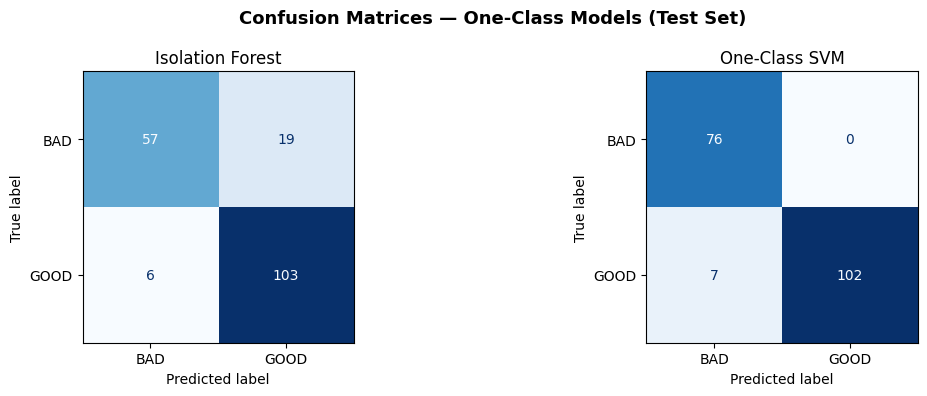

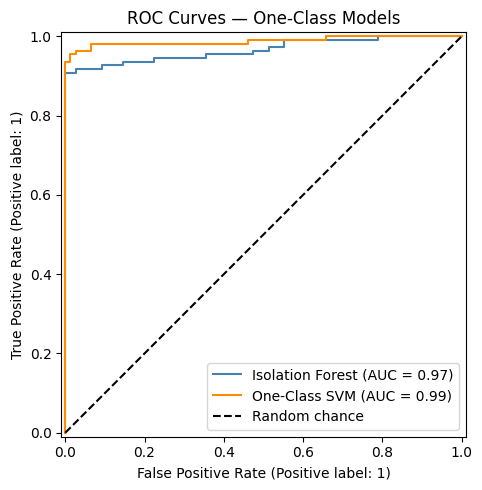

In [54]:
# --- Confusion matrices ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, pred, title in zip(
    axes,
    [pred_if, pred_svm],
    ["Isolation Forest", "One-Class SVM"]
):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, pred),
        display_labels=["BAD", "GOOD"]
    ).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title)
plt.suptitle("Confusion Matrices — One-Class Models (Test Set)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# --- ROC curves ---
fig, ax = plt.subplots(figsize=(7, 5))
for scores, name, color in [
    (scores_if,  "Isolation Forest", "steelblue"),
    (scores_svm, "One-Class SVM",    "darkorange"),
]:
    # Some sklearn versions do not accept a 'color' kwarg for from_predictions.
    # Call without color and then set color on the returned display line.
    disp = RocCurveDisplay.from_predictions(y_test, scores, name=name, ax=ax)
    try:
        disp.line_.set_color(color)
    except Exception:
        # Fallback: set the color of the axis line matching the label
        for line in ax.get_lines():
            if line.get_label() == name:
                line.set_color(color)
ax.plot([0, 1], [0, 1], "k--", label="Random chance")
ax.set_title("ROC Curves — One-Class Models")
ax.legend()
plt.tight_layout()
plt.show()

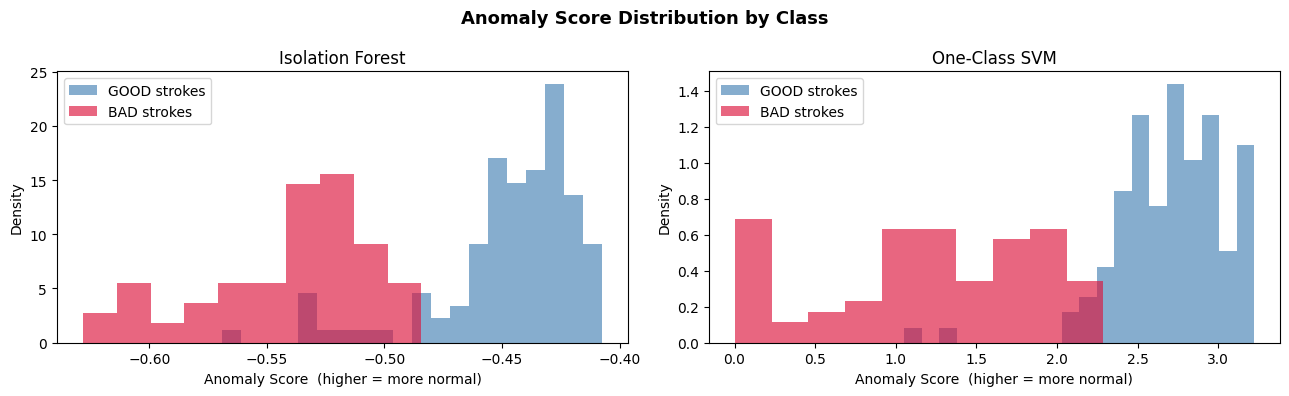

In [55]:
# --- Anomaly score distributions ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, scores, title in zip(
    axes,
    [scores_if, scores_svm],
    ["Isolation Forest", "One-Class SVM"]
):
    ax.hist(scores[y_test == 1], bins=20, alpha=0.65, color="steelblue", label="GOOD strokes", density=True)
    ax.hist(scores[y_test == 0], bins=10, alpha=0.65, color="crimson",   label="BAD strokes",  density=True)
    ax.set_xlabel("Anomaly Score  (higher = more normal)")
    ax.set_ylabel("Density")
    ax.set_title(title)
    ax.legend()
plt.suptitle("Anomaly Score Distribution by Class", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## Comparative Analysis

### Supervised Random Forest baseline (stroke-level)

For a fair comparison, the baseline Random Forest is retrained on the same stroke-level features. It uses a stratified split that includes BAD strokes in training — the key difference from our one-class approach.

**Important caveat**: the test sets are not identical:
- One-class: tests on all BAD strokes (more reliable BAD-detection estimate)
- Supervised RF: tests on ~20 % of all strokes (stratified; few BAD strokes end up in test)

Direct metric comparison is therefore indicative rather than strict. The conceptual difference is what matters most.


In [56]:
# Supervised RF on stroke-level features (includes BAD in training)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_rf_idx, test_rf_idx = next(sss.split(X_stroke, y_stroke))

scaler_rf   = StandardScaler()
X_rf_train  = scaler_rf.fit_transform(X_stroke[train_rf_idx])
X_rf_test   = scaler_rf.transform(X_stroke[test_rf_idx])
y_rf_train  = y_stroke[train_rf_idx]
y_rf_test   = y_stroke[test_rf_idx]

rf = RandomForestClassifier(
    n_estimators=100, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_rf_train, y_rf_train)

rf_proba  = rf.predict_proba(X_rf_test)[:, 1]
rf_pred   = rf.predict(X_rf_test)
rf_report = classification_report(y_rf_test, rf_pred, target_names=["BAD", "GOOD"], output_dict=True)

bad_sources = ", ".join(df.loc[df["BAD"] == 1, "source"].unique())
print(f"Supervised Random Forest (stroke-level)")
print(f"  BAD strokes in training set : {int((y_rf_train == 0).sum())}  (from {bad_sources})")
print(f"  BAD strokes in test set     : {int((y_rf_test  == 0).sum())}")
print(f"  ROC-AUC   : {roc_auc_score(y_rf_test, rf_proba):.4f}")
print(f"  Macro F1  : {f1_score(y_rf_test, rf_pred, average='macro'):.4f}")
print(f"  BAD Recall: {rf_report['BAD']['recall']:.4f}")
print()
print(classification_report(y_rf_test, rf_pred, target_names=["BAD", "GOOD"]))


Supervised Random Forest (stroke-level)
  BAD strokes in training set : 61  (from cla-BAD-2, cla-BAD)
  BAD strokes in test set     : 15
  ROC-AUC   : 1.0000
  Macro F1  : 0.9597
  BAD Recall: 0.8667

              precision    recall  f1-score   support

         BAD       1.00      0.87      0.93        15
        GOOD       0.98      1.00      0.99       109

    accuracy                           0.98       124
   macro avg       0.99      0.93      0.96       124
weighted avg       0.98      0.98      0.98       124



In [57]:
# Summary table
if_auc = roc_auc_score(y_test, scores_if)
if_f1  = f1_score(y_test, pred_if, average="macro")
if_rec = classification_report(y_test, pred_if,  target_names=["BAD","GOOD"], output_dict=True)["BAD"]["recall"]

svm_auc = roc_auc_score(y_test, scores_svm)
svm_f1  = f1_score(y_test, pred_svm, average="macro")
svm_rec = classification_report(y_test, pred_svm, target_names=["BAD","GOOD"], output_dict=True)["BAD"]["recall"]

rf_auc_val = roc_auc_score(y_rf_test, rf_proba)
rf_f1_val  = f1_score(y_rf_test, rf_pred, average="macro")
rf_rec_val = rf_report["BAD"]["recall"]

print(f"{'Model':<32} {'ROC-AUC':>8} {'Macro F1':>9} {'BAD Recall':>11} {'BAD in Train':>13}")
print("-" * 77)
print(f"  {'Isolation Forest':<30} {if_auc:>8.4f} {if_f1:>9.4f} {if_rec:>11.4f} {'No':>13}")
print(f"  {'One-Class SVM':<30} {svm_auc:>8.4f} {svm_f1:>9.4f} {svm_rec:>11.4f} {'No':>13}")
print(f"  {'Random Forest (supervised)':<30} {rf_auc_val:>8.4f} {rf_f1_val:>9.4f} {rf_rec_val:>11.4f} {'Yes (cla-BAD)':>13}")
print()
print("Note: RF and one-class models use different test splits — direct numeric")
print("      comparison is approximate. See Comparative Analysis for discussion.")


Model                             ROC-AUC  Macro F1  BAD Recall  BAD in Train
-----------------------------------------------------------------------------
  Isolation Forest                 0.9658    0.8560      0.7500            No
  One-Class SVM                    0.9880    0.9614      1.0000            No
  Random Forest (supervised)       1.0000    0.9597      0.8667 Yes (cla-BAD)

Note: RF and one-class models use different test splits — direct numeric
      comparison is approximate. See Comparative Analysis for discussion.


## Discussion

### What the numbers show

- The one-class models detect BAD strokes **without ever having seen one** during training. Any BAD recall > 0 demonstrates that the anomaly score captures genuine technique differences, not just video identity.
- The supervised RF benefits from seeing BAD examples during training (all from the same BAD video(s)). Its high test performance is partly inflated by this video-level confounding.

### Generalizability

| Scenario | Supervised RF | One-Class Models |
|----------|--------------|------------------|
| New rower, bad technique | Likely fails — never saw bad technique from this person | Can flag it — learned GOOD from multiple rowers |
| New camera angle / lighting | May fail — video features influenced training | More robust — trained on posture geometry, not video appearance |
| More BAD videos available | Helps, but confounding risk remains | BAD videos useful only for evaluation |

### Limitations of this approach

- The number of BAD strokes in evaluation is small; confidence intervals on BAD Recall are wide.
- Stroke-level aggregation (mean + std) loses temporal information within the stroke. A sequence model (LSTM, 1D-CNN) could capture the stroke *trajectory* instead of just its statistics.
- Adding more diverse GOOD rowers would strengthen what the model considers "normal".

### Conclusion

One-class classification reframes the problem in a way that is more honest about what the data can support. By defining normality from GOOD examples only, the models learn technique geometry rather than video identity, making them a more robust foundation for a real-world stroke quality detector.
